In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
#from tensorflow.keras.applications.vgg16 import decode_predictions
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

loading raccoon image folder...
*completed raccoon folder*
loading deer image folder...
*completed deer folder*
loading squirrel image folder...
*completed squirrel folder*


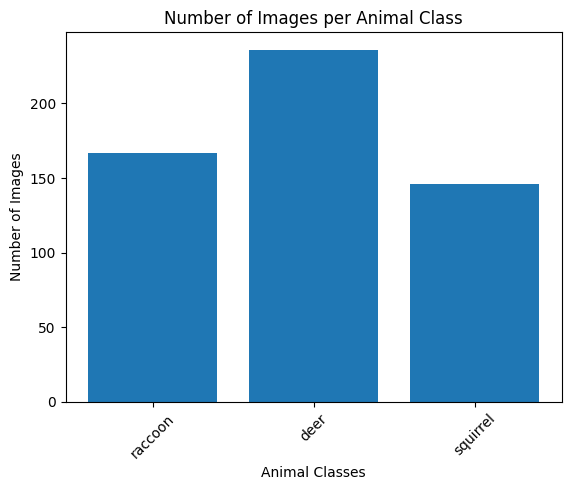

In [16]:
### Image Loading and Resizing, Data metrics
animals = ['raccoon','deer','squirrel']
img_data_arr = []
class_label_arr = []

datadir = "/Users/maneliiranmanesh/Desktop/School - Rutgers/Capstone/gardenPal_imgset"
feature_shape = () # variable to print out the feature array's size
num_img_per_animal = [] # array holding number of images per folder
for i in animals:
    print(f"loading {i} image folder...")
    path = os.path.join(datadir, i)
    num_img_per_animal.append(len(os.listdir(path))) # append number of images in each animal folder
    for img_file in os.listdir(path):
        img_path = os.path.join(path, img_file)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224), color_mode="rgb") # loads image, sizes it to 224x224, and forces it to be rgb (handles a couple of transparent images)
        img_array = tf.keras.preprocessing.image.img_to_array(img) # Turns the image into a numpy array
        img_data_arr.append(img_array) # appends single image array to total image array
        class_label_arr.append(animals.index(i)) # appends that image's class to total class array
    print(f"*completed {i} folder*")

# Convert to numpy
img_data = np.array(img_data_arr, dtype="float32")
class_labels = np.array(class_label_arr)


# Bar chart of Images per Animal Class
plt.bar(animals, num_img_per_animal)
plt.xlabel('Animal Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.title('Number of Images per Animal Class')
plt.show()


In [8]:
# using MobileNetV2 as a feature extractor and do include_top = False so it only returns 1280 size feature array
cnn_mobileV2 = MobileNetV2(weights="imagenet", input_shape = (224, 224, 3), include_top=False)
cnn_mobileV2.trainable = False  # freeze model so it doesn't use different weights for the train/test

# split train, test, and validation data before model training
X_train, X_temp, y_train, y_temp = train_test_split(img_data, class_labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# Build Model: Data Augmentation to include random and realistic transformations to data, Uses MobileNetV2 for transfer learning
#              and preprocessing, and custom layers with reLU and softmax activation functions.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1), #layers.RandomZoom(0.1),
]) # Artificially increases the diversity and size of the training dataset by applying random, realistic transformations

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs) # Each training image gets randomly modified, each epoch gets slightly different version
x = preprocess_input(x) # Converts pixel values from [0, 255] → [-1, 1] because MobileNetV2 uses this format
x = cnn_mobileV2(x, training=False) # Detects edges, textures, shapes, patterns, returns feature map (7 x 7 x 1280 size)

x = layers.GlobalAveragePooling2D()(x) # Flattens to 1280 array
x = layers.Dense(128, activation='relu')(x) # learns patterns in this dataset regarding each animal class
x = layers.Dropout(0.3)(x) # randomly turns off 30% of neurons to prevent overfitting
output = layers.Dense(len(animals), activation='softmax')(x) # labels the output as probabilities for each class

model = models.Model(inputs=inputs, outputs=output)


In [11]:
# Compile and train the model with training data
model.compile(
    optimizer='adam', # adam (adaptive moment estimation) optimizer
    loss='sparse_categorical_crossentropy', # (for 0-7 labels)
    metrics=['accuracy'] 
)

model.fit(x=X_train, y=y_train, epochs=10, validation_data = (X_val,y_val), batch_size=16)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8125 - loss: 0.4960 - val_accuracy: 0.9756 - val_loss: 0.0820
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9766 - loss: 0.0864 - val_accuracy: 0.9634 - val_loss: 0.0752
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9948 - loss: 0.0341 - val_accuracy: 0.9512 - val_loss: 0.0801
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9896 - loss: 0.0297 - val_accuracy: 0.9878 - val_loss: 0.0463
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9948 - loss: 0.0241 - val_accuracy: 0.9878 - val_loss: 0.0391
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9818 - loss: 0.0282 - val_accuracy: 0.9756 - val_loss: 0.0636
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9896 - loss: 0.0222 - val_accuracy: 0.9878 - val_loss: 0.0530
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9948 - loss: 0.0177 - val_accuracy: 0.9634 - v

In [12]:
# Retrains model but unfreezes top layers while keeping earlier layers frozen to finetune the model to the weights in the dataset
cnn_mobileV2.trainable = True

class_weight = {0: 1.0, 1: 2.5, 2: 1.0}  # raccoon, deer, squirrel

# Freeze lower layers, unfreeze top ones
for layer in cnn_mobileV2.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x=X_train, y=y_train, epochs=15, validation_data = (X_val,y_val), class_weight=class_weight)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.9688 - loss: 0.1505 - val_accuracy: 0.9634 - val_loss: 0.0577
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.9792 - loss: 0.1955 - val_accuracy: 0.9756 - val_loss: 0.0512
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.9714 - loss: 0.1132 - val_accuracy: 0.9878 - val_loss: 0.0487
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9896 - loss: 0.0378 - val_accuracy: 0.9634 - val_loss: 0.0512
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.9844 - loss: 0.0666 - val_accuracy: 0.9634 - val_loss: 0.0514
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.9948 - loss: 0.0509 - val_accuracy: 0.9756 - val_loss: 0.0507
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9766 - loss: 0.1054 - val_accuracy: 0.9756 - val_loss: 0.0496
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.9922 - loss: 0.0434 - val_accuracy: 0.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 0.0019  
Model R-squared score on test data: [0.001871321932412684, 1.0]
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step
Test set's F1 Score: 1.0
Test set's Accuracy: 1.0


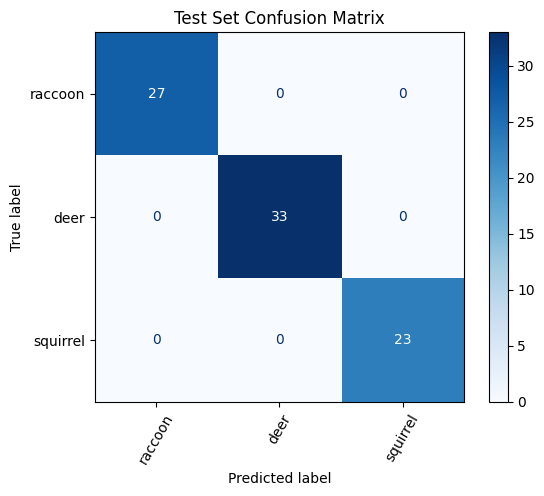

In [13]:
score = model.evaluate(X_test, y_test)
print(f"Model R-squared score on test data: {score}")

# Make predictions on the test data
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
print("Test set's F1 Score:", f1_score(y_test, y_pred, average="macro"))
print("Test set's Accuracy:", accuracy_score(y_test, y_pred))

confusion_test = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_test, display_labels=animals)
disp.plot(cmap="Blues", xticks_rotation=60)
plt.title("Test Set Confusion Matrix")
plt.show()

In [17]:
### Testing on real-world frozen test set
img_data_arr_TEST = []

datadir = "/Users/maneliiranmanesh/Desktop/School - Rutgers/Capstone/frozen_test_set"
files = sorted([f for f in os.listdir(datadir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

for img_file in files:
    img_path = os.path.join(datadir, img_file)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224), color_mode="rgb")
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_data_arr_TEST.append(img_array)

img_data = np.array(img_data_arr_TEST, dtype="float32")

label_map = {'raccoon': 0, 'deer': 1, 'squirrel': 2}
class_labels = np.array([label_map[f.split('_')[0]] for f in files])

predictions = model.predict(img_data)
y_predict_TEST = np.argmax(predictions, axis=1)
print(list(zip(files, y_predict_TEST)))  # lets you sanity-check which file got which prediction
print("New Test set's F1 Score:", f1_score(class_labels, y_predict_TEST, average="macro"))
print("New Test set's Accuracy:", accuracy_score(class_labels, y_predict_TEST))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[('deer_1.jpg', np.int64(1)), ('deer_2.jpg', np.int64(1)), ('raccoon_1.jpg', np.int64(0)), ('raccoon_2.jpg', np.int64(0)), ('squirrel_1.jpeg', np.int64(2)), ('squirrel_2.jpg', np.int64(2))]
New Test set's F1 Score: 1.0
New Test set's Accuracy: 1.0


In [18]:
### Sending Model via scp over to Raspberry PI

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("gardenPal_animal_model.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpr94ub131/assets


INFO:tensorflow:Assets written to: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpr94ub131/assets


Saved artifact at '/var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpr94ub131'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_166')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  5363950672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363950288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363947792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363952208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363951056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363952784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363951248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363953360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363952976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363950864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5363951632: Tens

W0000 00:00:1785368641.963587 3783437 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785368641.963607 3783437 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1785368641.964303 3783437 reader.cc:83] Reading SavedModel from: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpr94ub131
I0000 00:00:1785368641.968725 3783437 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1785368641.968729 3783437 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpr94ub131
I0000 00:00:1785368642.009682 3783437 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1785368642.018584 3783437 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1785368642.297484 3783437 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpr94ub131
I0000 00:00:1785368642.375040 3783437 lo

In [21]:
#import cv2
#import numpy as np

# Load model
#net = cv2.dnn.readNetFromCaffe(
    #"MobileNetSSD_deploy.prototxt",
    #"MobileNetSSD_deploy.caffemodel"
#)

# Class labels MobileNet was trained on
#CLASSES = ["background", "aeroplane", "bicycle", "bird", "boat",
           #"bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
           #"dog", "horse", "motorbike", "person", "pottedplant",
           #"sheep", "sofa", "train", "tvmonitor"]

#def detect_human(image_path):
    #frame = cv2.imread(image_path)

    #if frame is None:
        #print("Error: Could not load image")
        #return

    #h, w = frame.shape[:2]

    #blob = cv2.dnn.blobFromImage(frame, 0.007843, (300, 300), 127.5)
    #net.setInput(blob)
    #detections = net.forward()

    #for i in range(detections.shape[2]):
        #confidence = detections[0, 0, i, 2]

        #if confidence > 0.5:
            #idx = int(detections[0, 0, i, 1])

            #if CLASSES[idx] == "person":
                #return True  # Human found

    #return False  # No human

#datadir_human = r"C:\Users\Using Janani\Downloads\human1.jpg"
#datadir_dog = r"C:\Users\Using Janani\Downloads\gardenPal_testset\img1_dog.jpg"
#print(detect_human(datadir_human))
#print(detect_human(datadir_dog))
#import os; print(os.getcwd())
